#### analyze the memory capacity of the networks with fixed sequences and LoRA

In [ ]:
import torch.nn as nn
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sf_workingdir_lilly.dmlab.analysis.custom_esn_analysis import get_time_of_norm_threshold_crossing_fixed_sequence, len_new_orth_vec, len_new_orth_vec_new_not_norm, get_hidden_states_iso_feat, get_time_of_norm_threshold_crossing
from sf_workingdir_lilly.dmlab.custom_weight_generator import return_weights_for_iso_feat



In [ ]:
spec_rad = 1.4
time_steps = 70

Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
#trial=6
fixed_whh=True
fixed_wih=True

expanded_length = Hippo_R + Hippo_L - 1
hidden_size = Hippo_n_feature * expanded_length

x_vals = np.arange(1,70)

weight_trials = [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49]

seeds = [1111,2222,3333, 4444,5555]

In [3]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim47_lora.pkl", "rb") as f:
    trained_lora = pickle.load(f)

In [4]:
trained_lora.keys()

dict_keys([14, 39, 23, 45, 8, 22, 17, 15, 38, 4, 11, 1, 9, 3, 18, 33, 6, 12, 49, 43, 7, 41, 35, 5, 40, 42, 27, 36, 13, 24, 28, 30, 47, 29])

In [5]:

weights = dict()
for t in weight_trials:
    trial_weights = dict()
    for seed in seeds:
        wih, whh = return_weights_for_iso_feat(spec_rad, trial=t, fixed_whh=True, fixed_wih=True, vary_sparsity=False, sparsity=0.2, folder='weights')
        lr_column = trained_lora[t][seed]['lr_column']
        lr_row = trained_lora[t][seed]['lr_row']
        whh = whh + lr_column @ lr_row
        trial_weights[seed] = {'wih': wih, 'whh': whh}
    weights[t]=trial_weights



/tmp/ipykernel_3371280/3895111622.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  whh = whh + lr_column @ lr_row


In [6]:
weights.keys()

dict_keys([1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49])

In [7]:
# create the hidden states, input at the first time step and then zero inputs for the rest of the time steps
def get_hidden_states(W_ih, W_hh):
    rnn = nn.RNN(input_size=Hippo_n_feature, 
                        hidden_size=hidden_size,
                        num_layers=1, 
                        nonlinearity='relu',
                        batch_first=False,
                        bias=False)

    # fix the rnn weights
    W_ih = W_ih.detach()
    W_hh = W_hh.detach()
    W_ih = W_ih.to(rnn.weight_ih_l0.device, dtype=rnn.weight_ih_l0.dtype)
    W_hh = W_hh.to(rnn.weight_hh_l0.device, dtype=rnn.weight_hh_l0.dtype)
    with torch.no_grad():
        rnn.weight_ih_l0.copy_(W_ih)
        rnn.weight_hh_l0.copy_(W_hh)
    # Freeze RNN parameters.
    for param in rnn.parameters():
        param.requires_grad = False
    # create output vector (time steps x hidden size)
    hs = torch.zeros(time_steps, hidden_size)
    # first input
    u = torch.zeros(1,1,Hippo_n_feature) # shape: (1, B, n_feature)
    # u[:,0,0] = 1.0
    u[:,:,0] = 1.0
    h0 = torch.zeros(1,1,hidden_size)
    y, h = rnn.forward(u, h0)
    hs[0,:] = h
    # zero inputs for the amount of time steps
    for i in range(1, time_steps):
        u = torch.zeros(1,1,Hippo_n_feature)
        y, h = rnn.forward(u, h)
        # update the output vector: update the row corresponding to the current time step
        hs[i,:] = h
        i += 1
    return hs

hs = dict()
for t in weight_trials:
    trial_hs = dict()
    for seed in seeds:
        current_hs = get_hidden_states(weights[t][seed]['wih'], weights[t][seed]['whh'])
        trial_hs[seed] = current_hs
    hs[t]=trial_hs


#### Norm

In [9]:
norms = dict()
for t in weight_trials:
    trial_norm = dict()
    for seed in seeds:
        trial_norm[seed] = hs[t][seed].norm(dim=1)
    norms[t]=trial_norm


In [10]:
norms_thresh_crossed = dict()
for t in weight_trials:
    trial_norm_thresh_crossed = dict()
    for seed in seeds:
        trial_norm_thresh_crossed[seed] = get_time_of_norm_threshold_crossing_fixed_sequence(norms[t][seed], threshold=0.1)
    norms_thresh_crossed[t]=trial_norm_thresh_crossed

thresh  tensor(0.3561)
thresh  tensor(0.3561)
thresh  tensor(0.3561)
thresh  tensor(0.3561)
thresh  tensor(0.3561)
thresh  tensor(0.3007)
thresh  tensor(0.3007)
thresh  tensor(0.3007)
thresh  tensor(0.3007)
thresh  tensor(0.3007)
thresh  tensor(0.2978)
thresh  tensor(0.2978)
thresh  tensor(0.2978)
thresh  tensor(0.2978)
thresh  tensor(0.2978)
thresh  tensor(0.3294)
thresh  tensor(0.3294)
thresh  tensor(0.3294)
thresh  tensor(0.3294)
thresh  tensor(0.3294)
thresh  tensor(0.2758)
thresh  tensor(0.2758)
thresh  tensor(0.2758)
thresh  tensor(0.2758)
thresh  tensor(0.2758)
thresh  tensor(0.3014)
thresh  tensor(0.3014)
thresh  tensor(0.3014)
thresh  tensor(0.3014)
thresh  tensor(0.3014)
thresh  tensor(0.2995)
thresh  tensor(0.2995)
thresh  tensor(0.2995)
thresh  tensor(0.2995)
thresh  tensor(0.2995)
thresh  tensor(0.2970)
thresh  tensor(0.2970)
thresh  tensor(0.2970)
thresh  tensor(0.2970)
thresh  tensor(0.2970)
thresh  tensor(0.3260)
thresh  tensor(0.3260)
thresh  tensor(0.3260)
thresh  ten

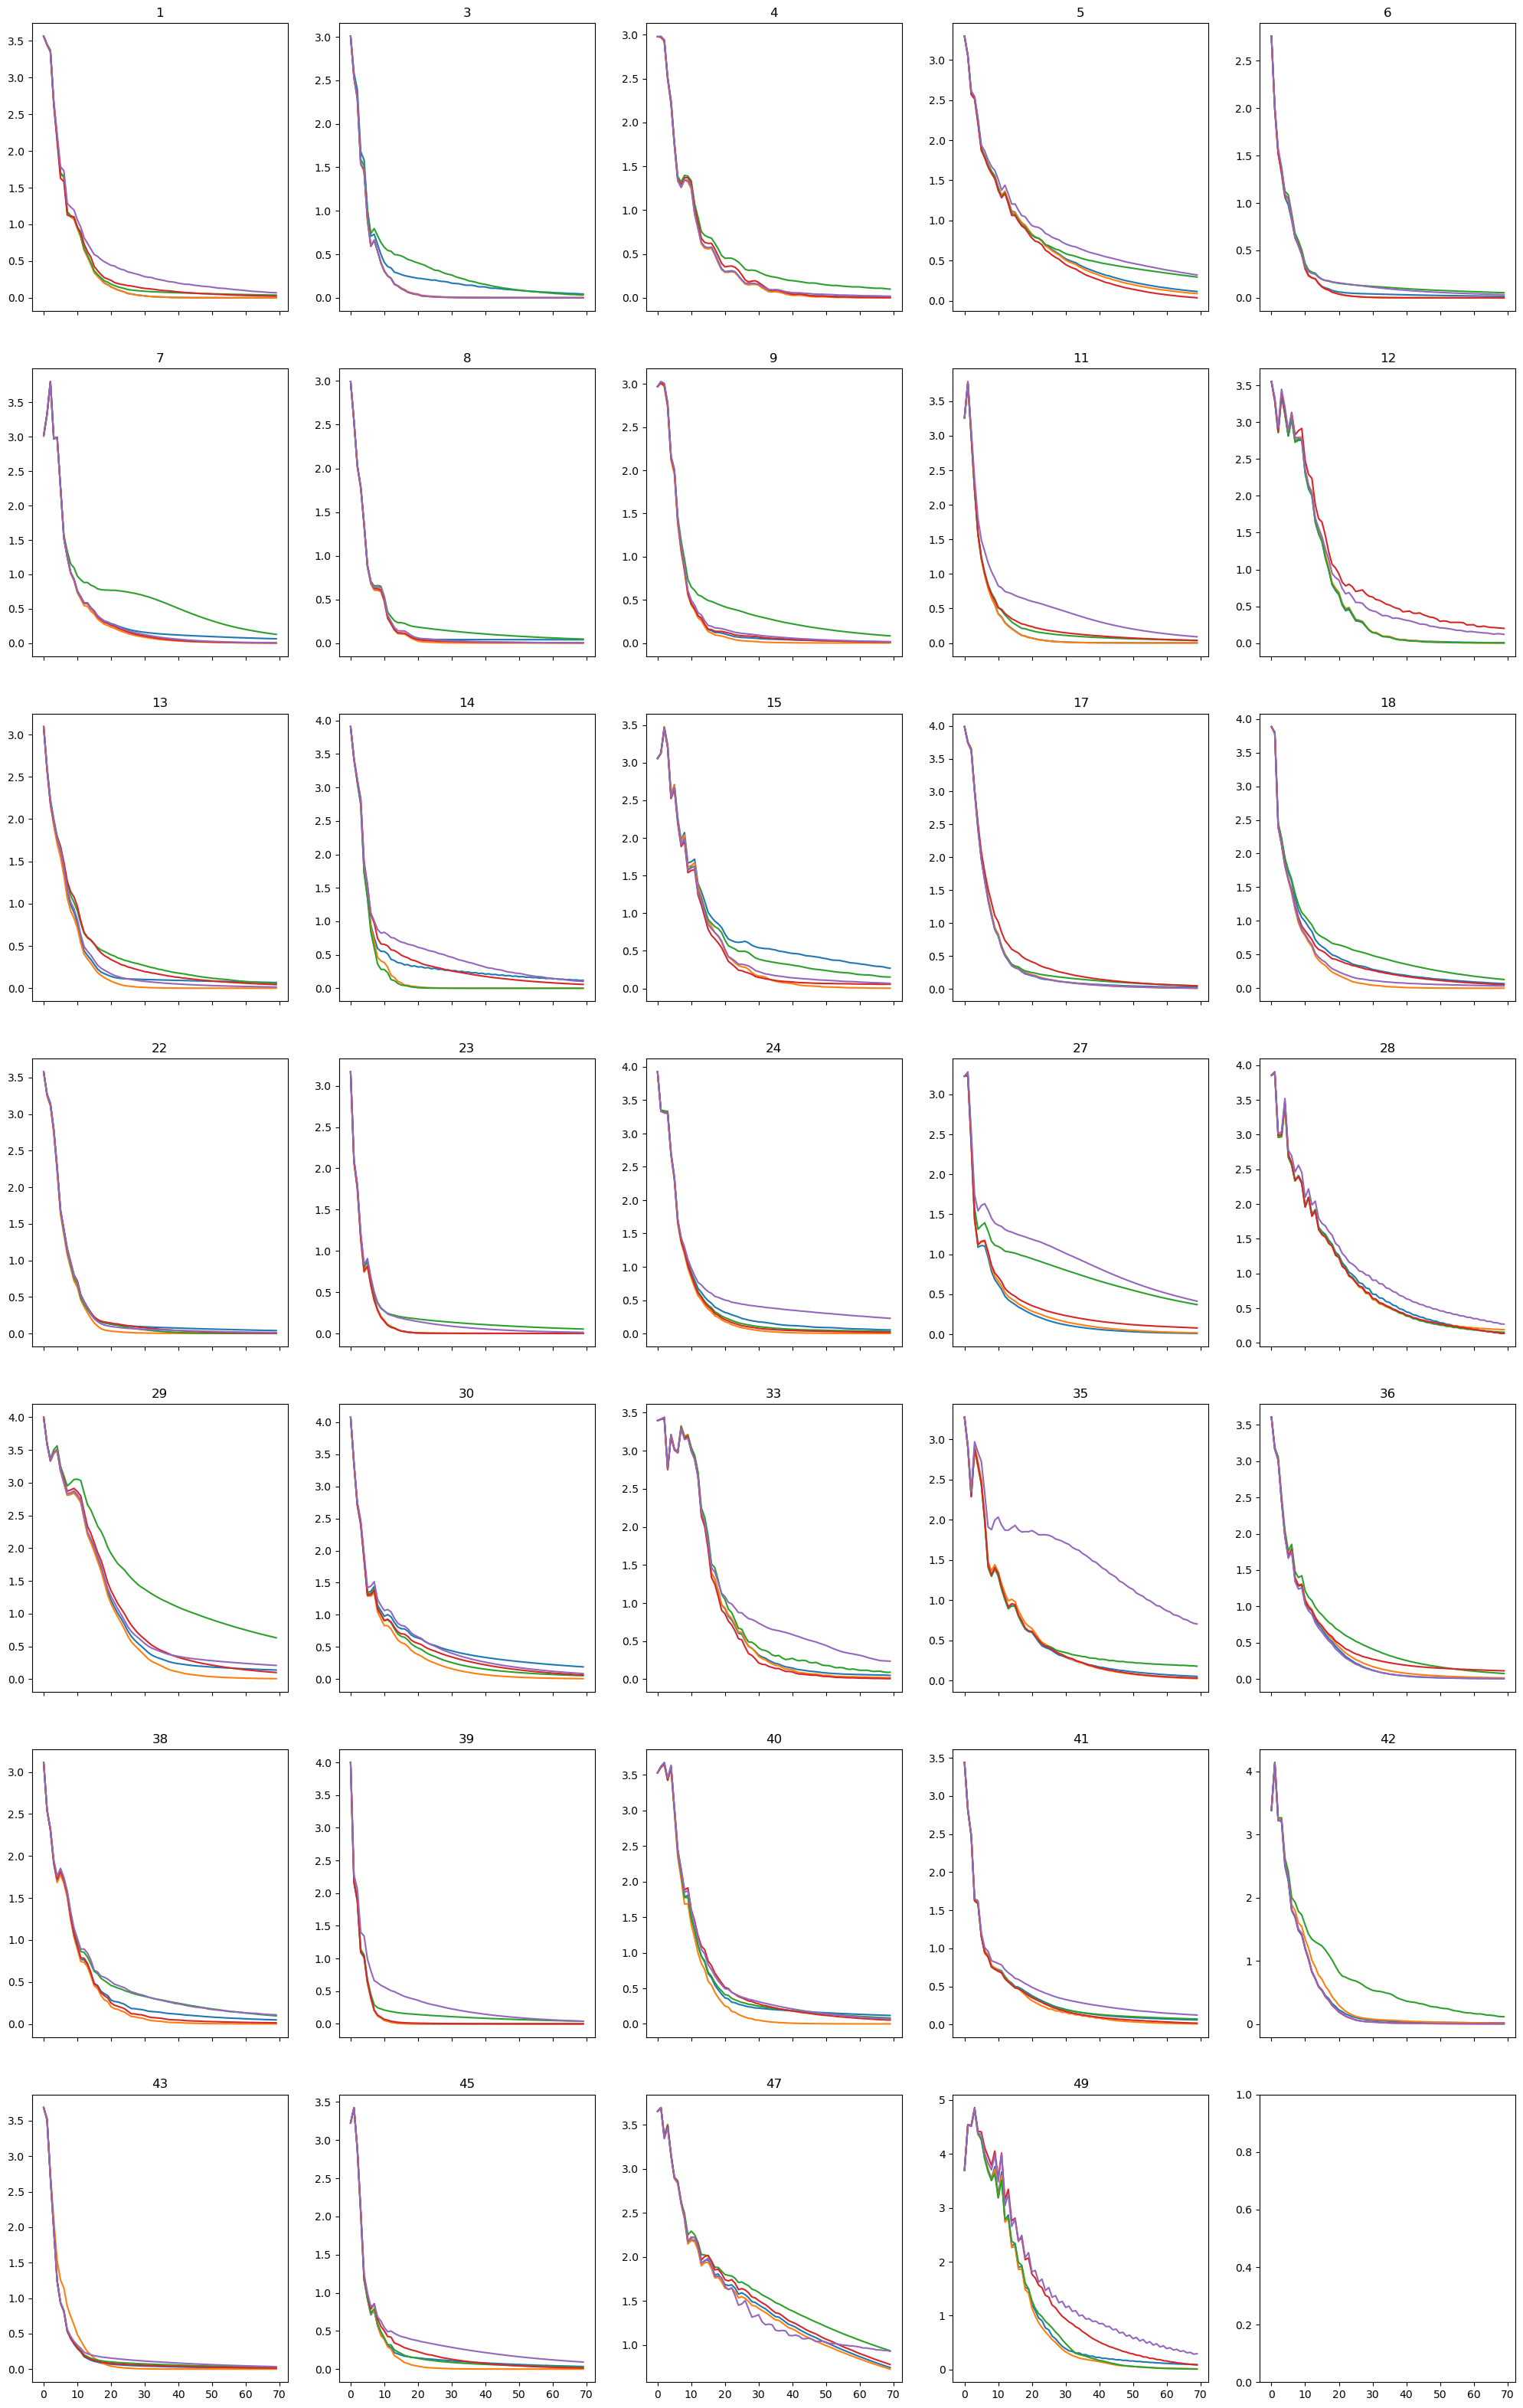

In [ ]:
x_vals = np.arange(1,70)

fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        ax[i//5, i%5].plot(norms[t][seed])
        ax[i//5, i%5].set_title(f'{t}')


#### orthogonal vector

In [8]:
# get the orthogonal vector not normalized
lens_orth_vec = dict()
for t in weight_trials:
    trial_lens_orth_vec = dict()
    for seed in seeds:
        try:
            trial_lens_orth_vec[seed] = len_new_orth_vec(hs[t][seed], time_steps)
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors')
    lens_orth_vec[t]=trial_lens_orth_vec



In [9]:
lens_orth_vec[1][5555]

array([0.8977548 , 0.83056355, 0.74240303, 0.72704256, 0.7288856 ,
       0.68145245, 0.65188736, 0.53240347, 0.4422991 , 0.37499276,
       0.3813655 , 0.2787106 , 0.2828236 , 0.24919878, 0.31214178,
       0.25763243, 0.26215178, 0.24537125, 0.21892641, 0.22184835,
       0.21692151, 0.20380886, 0.1954912 , 0.20666611, 0.20053878,
       0.18729362, 0.18199363, 0.17314851, 0.1757024 , 0.18115945,
       0.17161174, 0.1651695 , 0.17384171, 0.16323607, 0.15604614,
       0.16651538, 0.15564619, 0.15764254, 0.14403419, 0.14428228,
       0.14271362, 0.14121044, 0.12566772, 0.12165374, 0.11524671,
       0.11763452, 0.12141962, 0.11320152, 0.11429206, 0.11403649,
       0.11196947, 0.12183676, 0.1162466 , 0.1142826 , 0.09840419,
       0.09135376, 0.08796116, 0.08817033, 0.09432141, 0.10456561,
       0.1002775 , 0.09384052, 0.09141061, 0.09568799, 0.09448826,
       0.09449787, 0.08862469, 0.0834756 , 0.08405362], dtype=float32)

In [ ]:
x_vals = np.arange(1,70)
#fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)

orth_vec_lens_nolora = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i)
        try:
            len_orth_vectors = len_new_orth_vec(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens_nolora[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass
        #ax[t//5, t%5].set_title(f'{t}')

Could not compute length of orthogonal vectors for trial 24 and input neuron 5: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).
Could not compute length of orthogonal vectors for trial 38 and input neuron 6: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


NameError: name 'orth_vec_lens_nolora' is not defined

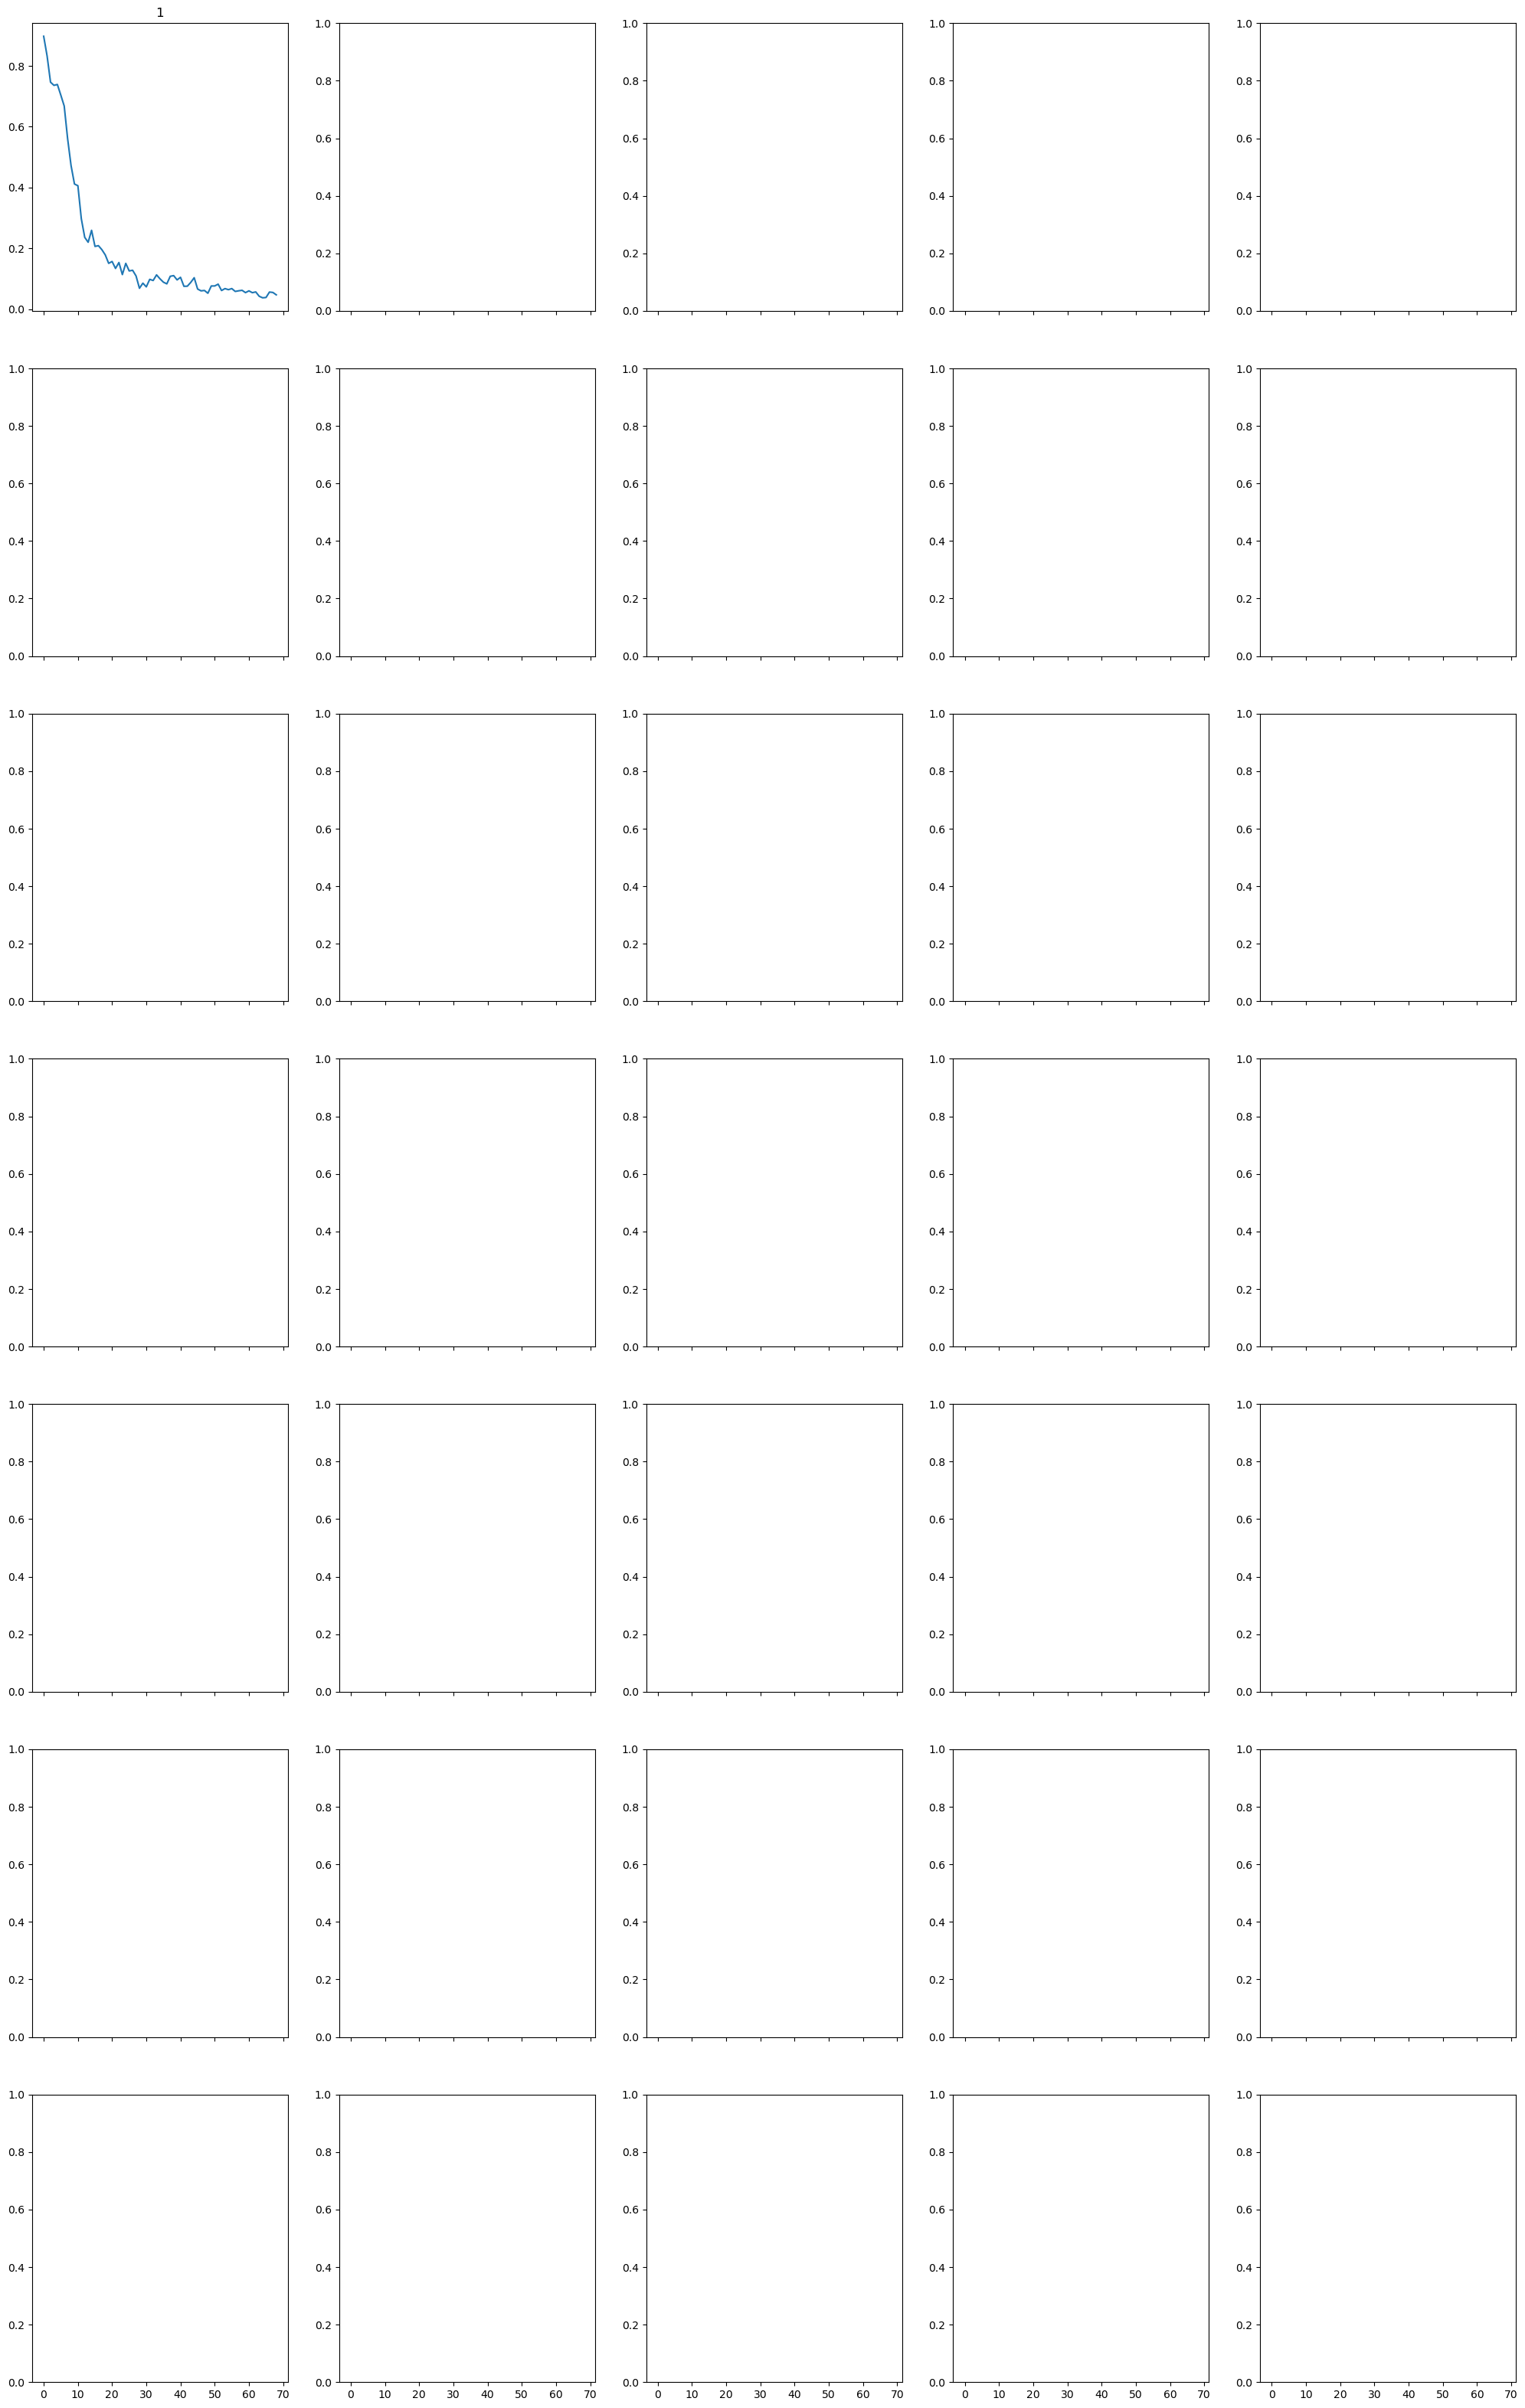

In [10]:

fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        ax[i//5, i%5].plot(lens_orth_vec[t][seed])
        ax[i//5, i%5].set_title(f'{t}')

        ax[i//5, i%5].scatter(x_vals, orth_vec_lens_nolora[t, 0, :], label=f'{i}', s=5, c='k')


In [ ]:
print(lens_orth_vec[1][1111])
print(get_time_of_norm_threshold_crossing_fixed_sequence(lens_orth_vec[1][1111]))

[0.8972675  0.8323962  0.7462719  0.73588836 0.7388178  0.7040236
 0.66801345 0.5602889  0.4723571  0.41153207 0.40598667 0.2974823
 0.23619467 0.22005367 0.25939262 0.20635912 0.20884497 0.19581807
 0.17854397 0.15067987 0.15683085 0.1339646  0.15348697 0.11374441
 0.1506803  0.12577984 0.12794878 0.10930546 0.06874645 0.08558615
 0.07341807 0.09812325 0.09429917 0.11275762 0.09984916 0.08880436
 0.0832855  0.10815165 0.11034835 0.09626716 0.10482457 0.07524291
 0.07561139 0.08815567 0.10348155 0.06631156 0.06031929 0.0615668
 0.05241399 0.07634415 0.0763371  0.08232436 0.06137813 0.06772532
 0.06416643 0.06774446 0.05835272 0.0604686  0.0620665  0.05443415
 0.06028077 0.0542586  0.0567632  0.04252896 0.03745957 0.03845399
 0.0563026  0.05503163 0.04714708]
28


In [ ]:
# get the threshold crossing
orth_thresh = dict()
for t in weight_trials:
    trial_orth_thresh = dict()
    for seed in seeds:
        trial_orth_thresh[seed] = get_time_of_norm_threshold_crossing_fixed_sequence(lens_orth_vec[t][seed], threshold=0.1)
    orth_thresh[t]=trial_orth_thresh


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [41]:
print(lens_orth_vec[49])
print(orth_thresh[49])

{1111: array([0.9359866 , 0.8447926 , 0.69799614, 0.58081734, 0.5093184 ,
       0.43834075, 0.4165868 , 0.44053465, 0.27325055, 0.30095565,
       0.2073644 , 0.19678327, 0.15495355, 0.17733905, 0.18220662,
       0.21791896, 0.19457057, 0.19114003, 0.17668897, 0.17452738,
       0.13047393, 0.12621783, 0.10944671, 0.10456681, 0.11230601,
       0.10965208, 0.11391299, 0.11615061, 0.11870404, 0.11796859,
       0.1267188 , 0.12496148, 0.14660372, 0.14780264, 0.15632069,
       0.13311084, 0.13175918, 0.12563406, 0.12793486, 0.12187801,
       0.13165274, 0.12043862, 0.13212726, 0.12068994, 0.12225304,
       0.10675088, 0.1036912 , 0.10241716, 0.10232934, 0.09206749,
       0.08947147, 0.07595076, 0.07839645, 0.07391939, 0.07904753,
       0.07180882, 0.07035966, 0.06835865, 0.06437812, 0.06468968,
       0.06458382, 0.05816144, 0.05899943, 0.06020337, 0.0585735 ,
       0.05723501, 0.05727891, 0.05408915, 0.04741476], dtype=float32), 2222: array([0.93600845, 0.8451843 , 0.70096433, 0

In [21]:
orth_thresh.keys()

dict_keys([1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49])

#### orthogonal vector not norm

In [ ]:
# get the orthogonal vector not normalized
try:
    len_orth_vectors_not_norm_2222 = len_new_orth_vec_new_not_norm(hs_2222, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

try:
    len_orth_vectors_not_norm_3333 = len_new_orth_vec_new_not_norm(hs_3333, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')        

try:   
    len_orth_vectors_not_norm_4444 = len_new_orth_vec_new_not_norm(hs_4444, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

try:
    len_orth_vectors_not_norm_5555 = len_new_orth_vec_new_not_norm(hs_5555, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

In [ ]:
x_vals = np.arange(1,70)
plt.figure()
#for i in range(Hippo_n_feature):
plt.plot(len_orth_vectors_not_norm_2222, label='Seed 2222')
plt.plot(len_orth_vectors_not_norm_3333, label='Seed 3333')
plt.plot(len_orth_vectors_not_norm_4444, label='Seed 4444')
plt.plot(len_orth_vectors_not_norm_5555, label='Seed 5555')
plt.xlabel('Time steps')
plt.legend()

In [ ]:
# get the threshold crossing
orth_not_norm_thresh_crossed_2222 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_2222, threshold=0.1)
orth_not_norm_thresh_crossed_3333 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_3333, threshold=0.1)
orth_not_norm_thresh_crossed_4444 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_4444, threshold=0.1)
orth_not_norm_thresh_crossed_5555 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_5555, threshold=0.1)

orth_not_norm_thresh_crossed = [orth_not_norm_thresh_crossed_2222, orth_not_norm_thresh_crossed_3333, orth_not_norm_thresh_crossed_4444, orth_not_norm_thresh_crossed_5555]

#### after Memory of Recurrent Networks: Do We Compute It Right? (Giovanni et al., 2024)

In [30]:
# 1) construct the Krylov matrix
def construct_krylov_matrix(whh, wih, time_steps):
    # C: w_ih, A: w_hh
    C, A = wih, whh
    K = torch.zeros((C.shape[0], time_steps))
    # input 
    u = torch.zeros(Hippo_n_feature)
    u[0] = 1.0
    # create a varaibel, so that the power of A does not need to be computed each time
    current_A = torch.linalg.matrix_power(A, 0)
    # C @ input
    C = C @ u

    for t in range(time_steps):
        col = current_A @ C 
        current_A = current_A @ A
        K[:, t] = col  
    return K

def compute_mc(whh, wih, time_steps):
    K = construct_krylov_matrix(whh, wih, time_steps)
    U, S, Vh = torch.linalg.svd(torch.tensor(K), full_matrices=False)

    tol = S.max() * max(K.shape) * torch.finfo(S.dtype).eps
    k = int((S > tol).sum().item())
    #print("effective k:", k)  

    # threshold the singular values
    Vh_k = Vh[:k, :]           # (k, m)
    P = Vh_k.T @ Vh_k          # (m, m) projector onto row-space
    MC = torch.diag(P)         # (m,) 
    return MC

In [ ]:

MC_mode_2222 = compute_mc(W_hh_2222, W_ih, time_steps)
MC_mode_3333 = compute_mc(W_hh_3333, W_ih, time_steps)
MC_mode_4444 = compute_mc(W_hh_4444, W_ih, time_steps)
MC_mode_5555 = compute_mc(W_hh_5555, W_ih, time_steps)

MC_sum_2222 = MC_mode_2222.sum().item()
MC_sum_3333 = MC_mode_3333.sum().item()
MC_sum_4444 = MC_mode_4444.sum().item()
MC_sum_5555 = MC_mode_5555.sum().item()

MC_sum = [MC_sum_2222, MC_sum_3333, MC_sum_4444, MC_sum_5555]

#### Xiaos' method SVD - singular value threshold

In [28]:
def compute_mc_svd_variance(whh, wih, time_steps, threshold=0.98):
    K = construct_krylov_matrix(whh, wih, time_steps) 
    U, S, Vh = torch.linalg.svd(torch.tensor(K), full_matrices=False)

    total_variance = (S**2).sum().item()
    # why squared singular values? because variance along each principal component is given by the square of the singular value
    variance_cumsum = torch.cumsum(S**2, dim=0)

    num_singular_values = 1
    i = 0
    while variance_cumsum[i] <= threshold * total_variance:
        num_singular_values += 1
        i += 1

    return num_singular_values

In [ ]:
# 
singular_components_krylov = dict()
for t in weight_trials:
    trial_singular_components_krylov = dict()
    for seed in seeds:
        trial_singular_components_krylov[seed] = compute_mc_svd_variance(weights[t][seed]['whh'], weights[t][seed]['wih'], time_steps)
    singular_components_krylov[t]=trial_singular_components_krylov

torch.Size([1136, 1136])
torch.Size([1136, 1136])


/tmp/ipykernel_435018/1271892696.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U, S, Vh = torch.linalg.svd(torch.tensor(K), full_matrices=False)


#### singular value threshold but with the hidden states, so the nonlinearity is included

In [ ]:
def compute_svd_variance_hs(hid_state, seed_idx, time_steps, threshold=0.98):
    #hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=0)  # (time_steps, hidden_size)
    current_hs = hid_state[seed_idx]
    U, S, Vh = torch.linalg.svd(torch.tensor(current_hs.T), full_matrices=False)

    total_variance = (S**2).sum().item()
    variance_cumsum = torch.cumsum(S**2, dim=0)
    num_singular_values = 1
    i = 0
    while variance_cumsum[i] <= threshold * total_variance:
        num_singular_values += 1
        i += 1

    return num_singular_values

In [ ]:
MC_singular_components_hs = []
for i, seed in enumerate(seeds):
    current_hs_MC = compute_svd_variance_hs(hs, i, time_steps, threshold=0.98)
    MC_singular_components_hs.append(current_hs_MC)


#### Participation ratio

In [ ]:
def compute_participation_ratio(whh, wih, time_steps, threshold=0.98):
    K = construct_krylov_matrix(whh, wih, time_steps) 
    K = K.to(dtype=torch.float64) 
    U, S, Vh = torch.linalg.svd(K, full_matrices=False)
    #S/=1e5
    eig_vals = S**2
    #print("eigenvalues:", eig_vals)
    pr = (eig_vals.sum().item())**2 / (eig_vals**2).sum().item()
    return pr

In [ ]:
participation_ratios = []
for i, seed in enumerate(seeds):
    current_pr = compute_participation_ratio(W_hh[i], W_ih, time_steps, threshold=0.98)
    participation_ratios.append(current_pr)

#### save the measures

In [ ]:
mc_measures = {'orth_vec_thresh_crossed': orth_thresh_crossed,
               'orth_vec_thresh_crossed_not_norm': orth_not_norm_thresh_crossed,
               'norm_thresh_crossed': tresh_crossed_norms,
               'summed_MC_svd': MC_sum,
               'MC_singular_components_svd': MC_singular_components,
               'MC_singular_components_hs_svd': MC_singular_components_hs,
               'participation_ratio_svd': participation_ratios
               }

In [37]:
mc_measures = {
               'orth_vec_thresh_crossed_not_norm': orth_thresh,
               'MC_singular_components_svd': singular_components_krylov,
               }

In [38]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measureslora47.pkl", "wb") as f:
    pickle.dump(mc_measures, f)